In [1]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import pandas as pd

In [2]:
train_df=pd.read_csv(r"C:\Users\BEST LAPTOP\OneDrive\AI\tensorflow\mnist\mnist\train.csv")
train_df

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41995,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
41996,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
41997,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
41998,6,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [3]:
train_df.label.value_counts()

label
1    4684
7    4401
3    4351
9    4188
2    4177
6    4137
0    4132
4    4072
8    4063
5    3795
Name: count, dtype: int64

In [4]:
test_df = pd.read_csv(r"C:\Users\BEST LAPTOP\OneDrive\AI\tensorflow\mnist\mnist\test.csv")
test_df

,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27995,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
27996,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
27997,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
27998,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [5]:
print("Train data shape: {}\n Test data shape: {}".format(train_df.shape, test_df.shape))

Train data shape: (42000, 785)
 Test data shape: (28000, 784)


In [6]:
X_train = train_df.drop("label", axis = 1)
Y_train = train_df["label"]
X_test = test_df
print(X_train.shape, Y_train.shape, X_test.shape)

(42000, 784) (42000,) (28000, 784)


In [7]:
# Normalization 
# x = x - min(x) / max(x) - min(x)
X_train = X_train/255
X_test = X_test/255

In [8]:
#  CONVERT TO NUMPY
# TensorFlow works best with NumPy arrays

X_train = X_train.values
Y_train = Y_train.values
X_test = X_test.values

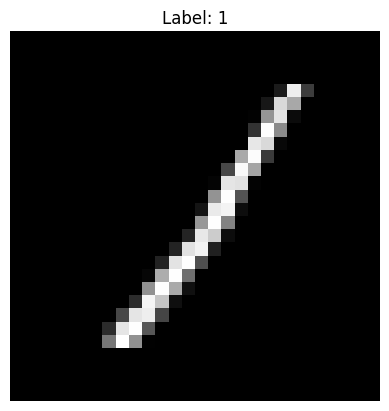

In [9]:
# 6. VISUALIZE RANDOM TRAIN IMAGE

idx = np.random.randint(0, len(X_train))
image = X_train[idx].reshape(28, 28)

plt.imshow(image, cmap='gray')
plt.title(f"Label: {Y_train[idx]}")
plt.axis('off')
plt.show()

In [10]:
# 7. BUILD MLP MODEL (NO CNN)

model = keras.Sequential([
    
    # Input layer (784 pixels)
    keras.layers.Dense(128, activation='relu', input_shape=(784,)),
    
    # Hidden layer
    keras.layers.Dense(64, activation='relu'),
    
    # Output layer (10 classes)
    keras.layers.Dense(10, activation='softmax')
])

print("\nModel Summary:")
model.summary()

c:\Users\BEST LAPTOP\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Model Summary:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
# 8. COMPILE MODEL

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [12]:
# 9. TRAIN MODEL

history = model.fit(
    X_train, Y_train,
    epochs=10,
    batch_size=32
)

Epoch 1/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.9183 - loss: 0.2769
Epoch 2/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9655 - loss: 0.1155
Epoch 3/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9748 - loss: 0.0794
Epoch 4/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9810 - loss: 0.0590
Epoch 5/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9842 - loss: 0.0482
Epoch 6/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9871 - loss: 0.0384
Epoch 7/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9902 - loss: 0.0309
Epoch 8/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9910 - loss: 0.0254
Epoch 9/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9939 - loss: 0.0193
Epoch 10/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.9927 - loss: 0.0220


In [13]:
# 10. PREDICT ON TEST DATA

predictions = model.predict(X_test)

# Convert probabilities → final labels
pred_labels = np.argmax(predictions, axis=1)

print("\nFirst 10 Predictions:")
print(pred_labels[:10])

875/875 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step

First 10 Predictions:
[2 0 9 9 3 9 0 3 0 3]


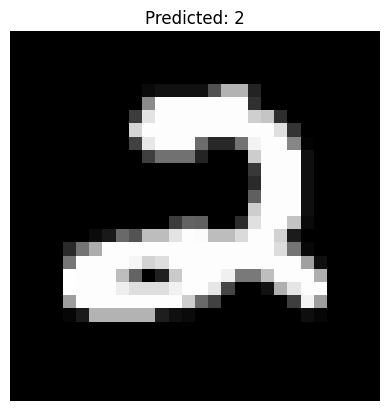

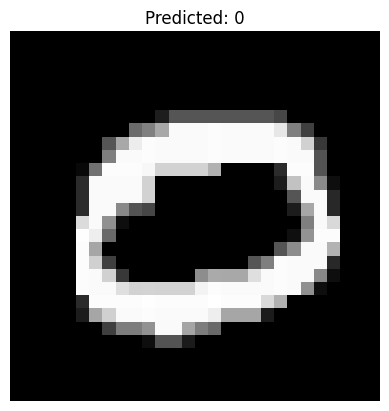

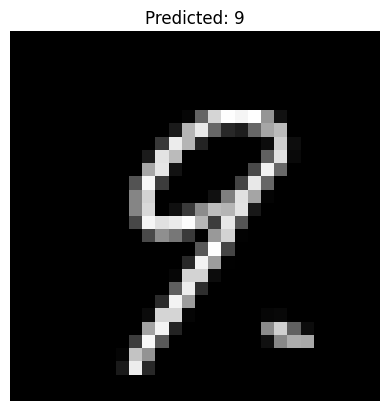

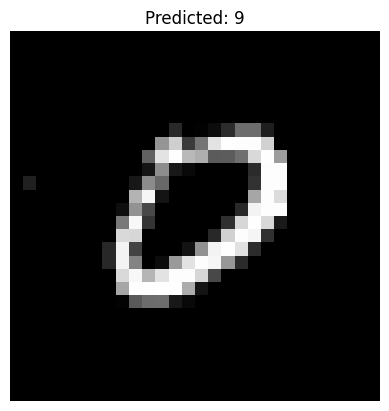

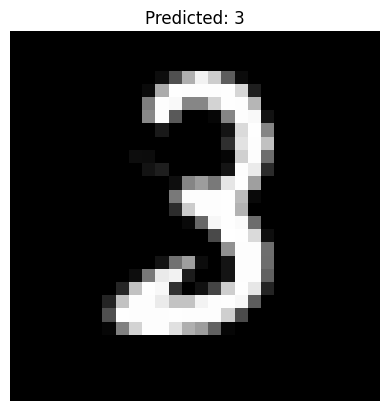

In [14]:
#  VISUALIZE TEST PREDICTIONS

for i in range(5):
    image = X_test[i].reshape(28, 28)
    
    plt.imshow(image, cmap='gray')
    plt.title(f"Predicted: {pred_labels[i]}")
    plt.axis('off')
    plt.show()

In [15]:
# DISPLAY FINAL TRAINING ACCURACY

final_acc = history.history['accuracy'][-1]
final_loss = history.history['loss'][-1]

print("\nFinal Training Accuracy:", final_acc)
print("Final Training Loss:", final_loss)


Final Training Accuracy: 0.9926905035972595
Final Training Loss: 0.021975690498948097


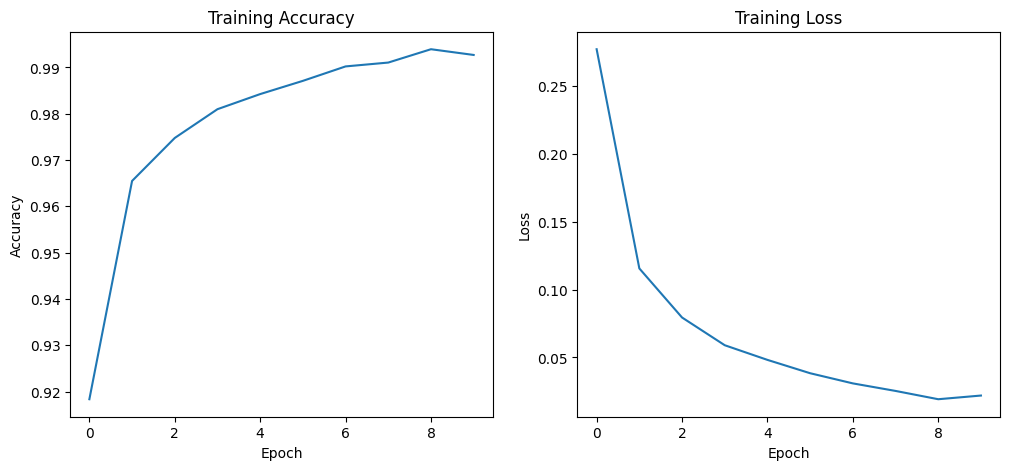

In [16]:
# PLOT TRAINING ACCURACY & LOSS

plt.figure(figsize=(12, 5))

# ---- Accuracy Plot ----
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.title("Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

# ---- Loss Plot ----
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.show()

In [17]:
# SAVE TRAINED MODEL

model.save("mnist_mlp_model.h5")

print("Model saved successfully!")

Model saved successfully!


In [18]:

# LOAD SAVED MODEL

from tensorflow import keras

loaded_model = keras.models.load_model("mnist_mlp_model.h5")

print("Model loaded successfully!")

Model loaded successfully!


In [19]:
predictions = loaded_model.predict(X_test)

# Convert probabilities → labels
pred_labels = np.argmax(predictions, axis=1)

print("First 10 Predictions:")
print(pred_labels[:10])

875/875 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
First 10 Predictions:
[2 0 9 9 3 9 0 3 0 3]


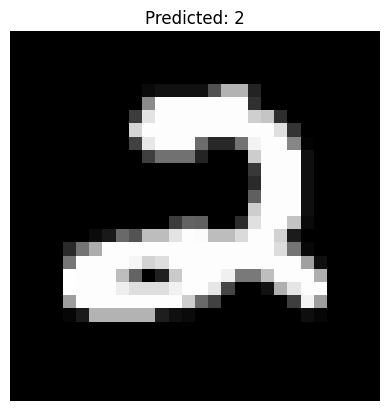

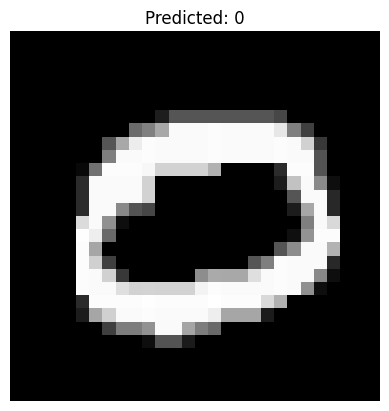

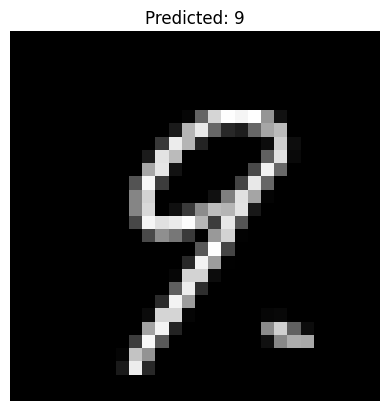

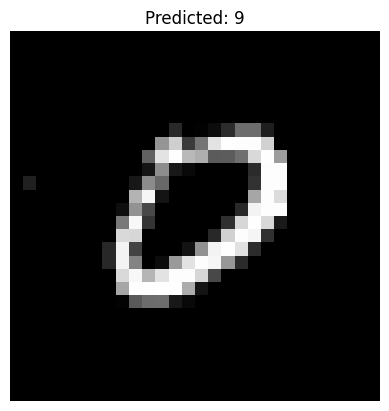

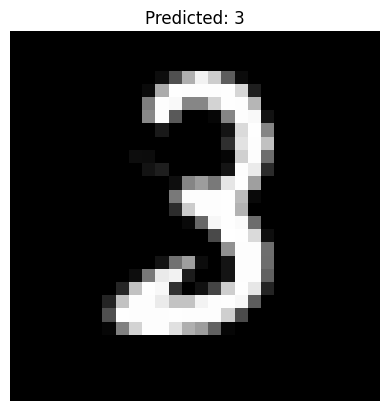

In [20]:
import matplotlib.pyplot as plt

for i in range(5):
    image = X_test[i].reshape(28, 28)
    
    plt.imshow(image, cmap='gray')
    plt.title(f"Predicted: {pred_labels[i]}")
    plt.axis('off')
    plt.show()